<a href="https://colab.research.google.com/github/chance-ineza/Building-Makemore-LLM/blob/main/AI_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Neural Networks and Backprograpagation

1. Makemore

In [ ]:
words = open('names.txt', 'r').read().splitlines()

b = {}
for w in words:
  ch = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(ch, ch[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

count = sorted(b.items(), key= lambda k: -k[1])

In [ ]:
import torch
N = torch.zeros((28, 28), dtype =torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i for i, s in enumerate(chars)}
stoi['<S>'] = 26
stoi['<E>'] = 27
for w in words:
  ch = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(ch, ch[1:]):
    N[stoi[ch1],stoi[ch2]] += 1


Makemore MLP (Part 2)

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt


--2026-07-05 23:10:13--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-07-05 23:10:13 (8.14 MB/s) - ‘names.txt’ saved [228145/228145]



In [13]:
words = open('names.txt', 'r').read().splitlines()

In [ ]:
words = open('names.txt', 'r').read().splitlines()
print(f'Reloaded {len(words)} words from names.txt')

In [27]:
# build the vocabulary of characters and mappings to/from integers
charS = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(charS)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [73]:
blocksize = 3

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * blocksize
    for ch in w + ".":
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), "-->", itos[ix])
      context = context[1:] + [ix]

  X = torch.tensor(X, dtype=torch.int64)
  Y = torch.tensor(Y, dtype=torch.int64)
  return X, Y

build_dataset(words)

(tensor([[ 0,  0,  0],
         [ 0,  0,  1],
         [ 0,  1, 22],
         [ 1, 22,  1],
         [ 0,  0,  0],
         [ 0,  0, 15],
         [ 0, 15, 12],
         [15, 12,  9],
         [12,  9, 22],
         [ 9, 22,  9],
         [22,  9,  1],
         [ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         [ 5, 13, 13],
         [13, 13,  1]]),
 tensor([ 1, 22,  1,  0, 15, 12,  9, 22,  9,  1,  0,  5, 13, 13,  1,  0]))

Train and Test datasets

In [74]:
import random

random.seed(100)
random.shuffle(words)

n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [ ]:
import random

random.seed(100)
random.shuffle(words)

n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

print(f'Train set size: {len(Xtr)} samples')
print(f'Dev set size: {len(Xdev)} samples')
print(f'Test set size: {len(Xtest)} samples')

Parameters

In [63]:
g = torch.Generator().manual_seed(478920348)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]

In [64]:
sum(p.nelement() for p in parameters) # number of parameters in total
for p in parameters:
  p.requires_grad = True

In [65]:
lre = torch.linspace(-3, 0, 10000)
lrs = 10**lre

lri = []
lossi = []
stepi = []


In [66]:
for i in range(2000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]]
  h  = torch.tanh(emb.view(-1, 6) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  # Update
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


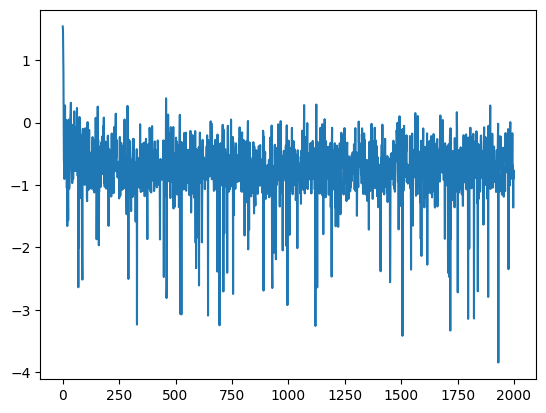

In [67]:
# Graph loss

plt.plot(stepi, lossi)

In [68]:
# Training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(0.1845, grad_fn=<NllLossBackward0>)

In [75]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(nan, grad_fn=<NllLossBackward0>)

In [77]:
# Recalculate validation loss after ensuring non-empty dev set
emb = C[Xdev] # (N_dev_samples, blocksize, embedding_dim)
h = torch.tanh(emb.view(-1, blocksize * C.shape[1]) @ W1 + b1) # (N_dev_samples, hidden_size)
logits = h @ W2 + b2 # (N_dev_samples, vocab_size)
loss = F.cross_entropy(logits, Ydev)
print(f'Validation loss: {loss.item()}')

Validation loss: nan


In [76]:
# test loss
emb = C[Xtest] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytest)
loss

tensor(0.4649, grad_fn=<NllLossBackward0>)